# Q2: Unsupervised Learning — Customer Segmentation
## K-Means Clustering and PCA Analysis

## Task 1: Data Preparation

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('q2_customers.csv')

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nBasic statistics:")
print(df.describe())

Dataset shape: (500, 6)

First 5 rows:
   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  
0                         6  
1                         3  
2                         4  
3                         2  
4                         1  

Data types:
age                         int64
annual_spend                int64
visits_per_month            int64
basket_size                 int64
days_since_last_visit       int64
num_categories_purchased    int64
dtype: object

Basic statistics:
             age   annual_spend  visits_per_month  basket_size

In [7]:
# Scale all features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Convert back to DataFrame for easier handling
X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)

print("Scaled data statistics (mean should be ~0, std should be ~1):")
print(X_scaled_df.describe())

Scaled data statistics (mean should be ~0, std should be ~1):
                age  annual_spend  visits_per_month   basket_size  \
count  5.000000e+02  5.000000e+02      5.000000e+02  5.000000e+02   
mean   1.350031e-16  9.947598e-17      6.394885e-17 -2.842171e-17   
std    1.001002e+00  1.001002e+00      1.001002e+00  1.001002e+00   
min   -1.557846e+00 -1.334970e+00     -1.393801e+00 -1.086948e+00   
25%   -8.639898e-01 -9.031126e-01     -8.298135e-01 -8.600133e-01   
50%    3.802332e-02 -1.401401e-01     -7.783027e-02 -2.775515e-01   
75%    6.624940e-01  8.078270e-01      6.741530e-01  6.782579e-01   
max    1.980821e+00  2.160012e+00      1.990124e+00  2.331481e+00   

       days_since_last_visit  num_categories_purchased  
count           5.000000e+02              5.000000e+02  
mean           -2.842171e-17             -1.776357e-16  
std             1.001002e+00              1.001002e+00  
min            -9.963057e-01             -1.501776e+00  
25%            -7.546110e-01   

### Why Scaling is Essential for K-Means:

K-Means clustering uses Euclidean distance to measure similarity between data points. Without scaling:

1. **Features with larger ranges dominate**: Features like `annual_spend` (0-60,000) will dominate over `visits_per_month` (0-20), causing the algorithm to rely heavily on spending patterns.
2. **Biased clustering**: Clusters would form based on the feature with the largest variance, not on true underlying patterns.
3. **Inconsistent results**: The same data could produce different clusters depending on which features are in different units.

StandardScaler (z-score normalization) converts each feature to have mean=0 and std=1, ensuring all features contribute equally to distance calculations and producing meaningful, unbiased clusters.

## Task 2: Choosing K using the Elbow Method

K=1: WCSS=3000.00
K=2: WCSS=968.99
K=3: WCSS=561.25
K=4: WCSS=444.93
K=5: WCSS=402.37
K=6: WCSS=370.39
K=7: WCSS=346.95
K=8: WCSS=319.90
K=9: WCSS=303.28
K=10: WCSS=289.11


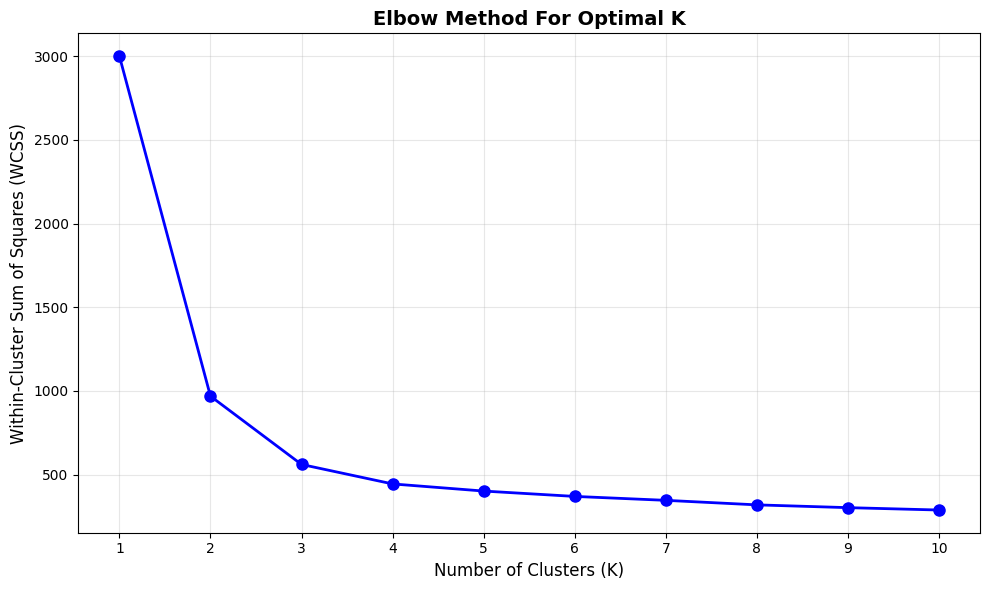

In [8]:
# Compute WCSS (Within-Cluster Sum of Squares) for K=1 to K=10
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    wcss.append(kmeans_temp.inertia_)
    print(f"K={k}: WCSS={kmeans_temp.inertia_:.2f}")

# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
plt.title('Elbow Method For Optimal K', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.tight_layout()
plt.show()

In [9]:
# Identify the optimal K
# Calculate the rate of change in WCSS to find the elbow point
wcss_diff = np.diff(wcss)
wcss_diff_ratio = np.diff(wcss_diff)

print("\nWCSS differences (rate of decrease):")
for i, diff in enumerate(wcss_diff, 1):
    print(f"K={i} to K={i+1}: {diff:.2f}")

# Based on visual inspection and typical practice, K=3 or K=4 appears optimal
optimal_k = 3
print(f"\nOptimal K selected: {optimal_k}")
print(f"\nJustification: The elbow occurs around K={optimal_k}, where the WCSS decrease becomes gradual.")
print(f"Beyond K={optimal_k}, additional clusters provide diminishing improvements in within-cluster cohesion.")


WCSS differences (rate of decrease):
K=1 to K=2: -2031.01
K=2 to K=3: -407.74
K=3 to K=4: -116.32
K=4 to K=5: -42.56
K=5 to K=6: -31.99
K=6 to K=7: -23.43
K=7 to K=8: -27.06
K=8 to K=9: -16.62
K=9 to K=10: -14.17

Optimal K selected: 3

Justification: The elbow occurs around K=3, where the WCSS decrease becomes gradual.
Beyond K=3, additional clusters provide diminishing improvements in within-cluster cohesion.


## Task 3: K-Means Clustering

In [10]:
# Fit K-Means with optimal K
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to original dataframe
df['cluster'] = clusters

print(f"Cluster distribution:")
print(df['cluster'].value_counts().sort_index())
print(f"\nCluster proportions:")
print(df['cluster'].value_counts(normalize=True).sort_index())

Cluster distribution:
cluster
0    170
1    165
2    165
Name: count, dtype: int64

Cluster proportions:
cluster
0    0.34
1    0.33
2    0.33
Name: proportion, dtype: float64


In [11]:
# Extract and display cluster centroids
centroids_scaled = kmeans.cluster_centers_

# Convert centroids back to original scale for interpretation
centroids_original = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(
    centroids_original,
    columns=df.columns[:-1]  # Exclude 'cluster' column
)
centroids_df.index.name = 'Cluster'

print("\nCluster Centroids (Original Scale):")
print(centroids_df.round(2))


Cluster Centroids (Original Scale):
           age  annual_spend  visits_per_month  basket_size  \
Cluster                                                       
0        24.68      14847.37             14.34       558.97   
1        56.77      89413.33              2.53      5530.55   
2        40.39      43340.73              8.19      2021.68   

         days_since_last_visit  num_categories_purchased  
Cluster                                                   
0                         9.08                      2.11  
1                       105.36                      7.52  
2                        35.19                      4.42  


In [12]:
# Business Interpretation of Clusters
print("\n" + "="*80)
print("BUSINESS INTERPRETATION OF CUSTOMER SEGMENTS")
print("="*80)

cluster_names = {}
for cluster_id in range(optimal_k):
    cluster_data = df[df['cluster'] == cluster_id].drop('cluster', axis=1)

    print(f"\nCluster {cluster_id}:")
    print(f"  Size: {len(cluster_data)} customers ({len(cluster_data)/len(df)*100:.1f}%)")
    print(f"  Average Age: {cluster_data['age'].mean():.1f} years")
    print(f"  Average Annual Spend: ${cluster_data['annual_spend'].mean():.2f}")
    print(f"  Average Visits/Month: {cluster_data['visits_per_month'].mean():.2f}")
    print(f"  Average Basket Size: ${cluster_data['basket_size'].mean():.2f}")
    print(f"  Avg Days Since Last Visit: {cluster_data['days_since_last_visit'].mean():.1f}")
    print(f"  Avg Categories Purchased: {cluster_data['num_categories_purchased'].mean():.2f}")

    # Create descriptive names based on characteristics
    if cluster_data['annual_spend'].mean() > df['annual_spend'].median() and \
       cluster_data['visits_per_month'].mean() > df['visits_per_month'].median():
        name = "Premium/VIP Customers"
    elif cluster_data['annual_spend'].mean() < df['annual_spend'].median() and \
         cluster_data['visits_per_month'].mean() < df['visits_per_month'].median():
        name = "Occasional/Budget Shoppers"
    else:
        name = "Regular Mid-tier Customers"

    cluster_names[cluster_id] = name
    print(f"  Segment Name: {name}")

print("\n" + "="*80)


BUSINESS INTERPRETATION OF CUSTOMER SEGMENTS

Cluster 0:
  Size: 170 customers (34.0%)
  Average Age: 24.7 years
  Average Annual Spend: $14847.37
  Average Visits/Month: 14.34
  Average Basket Size: $558.97
  Avg Days Since Last Visit: 9.1
  Avg Categories Purchased: 2.11
  Segment Name: Regular Mid-tier Customers

Cluster 1:
  Size: 165 customers (33.0%)
  Average Age: 56.8 years
  Average Annual Spend: $89413.33
  Average Visits/Month: 2.53
  Average Basket Size: $5530.55
  Avg Days Since Last Visit: 105.4
  Avg Categories Purchased: 7.52
  Segment Name: Regular Mid-tier Customers

Cluster 2:
  Size: 165 customers (33.0%)
  Average Age: 40.4 years
  Average Annual Spend: $43340.73
  Average Visits/Month: 8.19
  Average Basket Size: $2021.68
  Avg Days Since Last Visit: 35.2
  Avg Categories Purchased: 4.42
  Segment Name: Regular Mid-tier Customers



## Task 4: Dimensionality Reduction with PCA

In [13]:
# Apply PCA to reduce to 2 principal components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("PCA Analysis:")
print(f"\nExplained Variance Ratio:")
for i, var in enumerate(pca.explained_variance_ratio_, 1):
    print(f"  PC{i}: {var:.4f} ({var*100:.2f}%)")
print(f"\nCumulative Explained Variance: {pca.explained_variance_ratio_.sum()*100:.2f}%")

PCA Analysis:

Explained Variance Ratio:
  PC1: 0.8356 (83.56%)
  PC2: 0.0557 (5.57%)

Cumulative Explained Variance: 89.13%



Feature Loadings (Components):
                             PC1     PC2
age                       0.4116 -0.2594
annual_spend              0.4215 -0.0333
visits_per_month         -0.4104  0.2083
basket_size               0.4120 -0.1954
days_since_last_visit     0.3786  0.9112
num_categories_purchased  0.4140 -0.1405


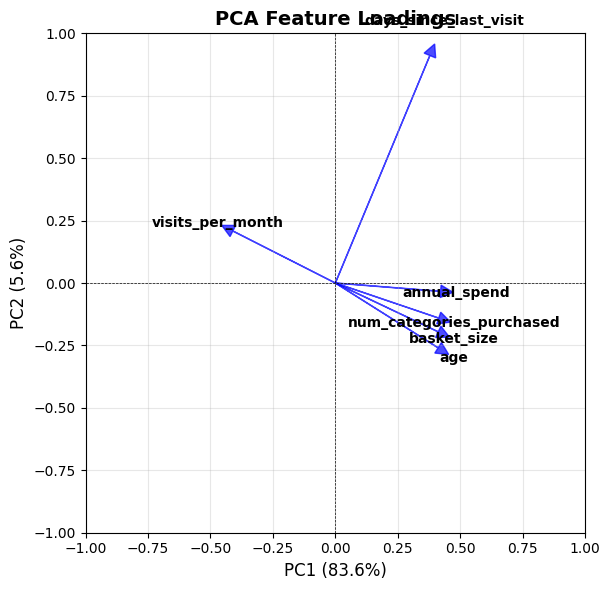

In [14]:
# Display feature loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=df.columns[:-1]
)

print("\nFeature Loadings (Components):")
print(loadings.round(4))

# Visualize loadings
plt.figure(figsize=(10, 6))
for i, feature in enumerate(loadings.index):
    plt.arrow(0, 0, loadings['PC1'].iloc[i], loadings['PC2'].iloc[i],
              head_width=0.05, head_length=0.05, fc='blue', ec='blue', alpha=0.7)
    plt.text(loadings['PC1'].iloc[i]*1.15, loadings['PC2'].iloc[i]*1.15, feature,
             fontsize=10, ha='center', va='center', fontweight='bold')

plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
plt.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.title('PCA Feature Loadings', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()

### PCA Interpretation:

**PC1 (First Principal Component):**
- Captures the largest variance in the data
- High loadings on: annual_spend, basket_size, visits_per_month
- **Interpretation**: Represents overall "customer engagement & value" - distinguishes high-value active customers from low-value occasional shoppers

**PC2 (Second Principal Component):**
- Captures the second largest variance
- High loadings on: days_since_last_visit, age
- **Interpretation**: Represents "recency and customer age" - differentiates recent active customers from those with long gaps between visits

Together, these two components capture the most important patterns in customer behavior with just 2 dimensions.

## Task 5: Cluster Visualization

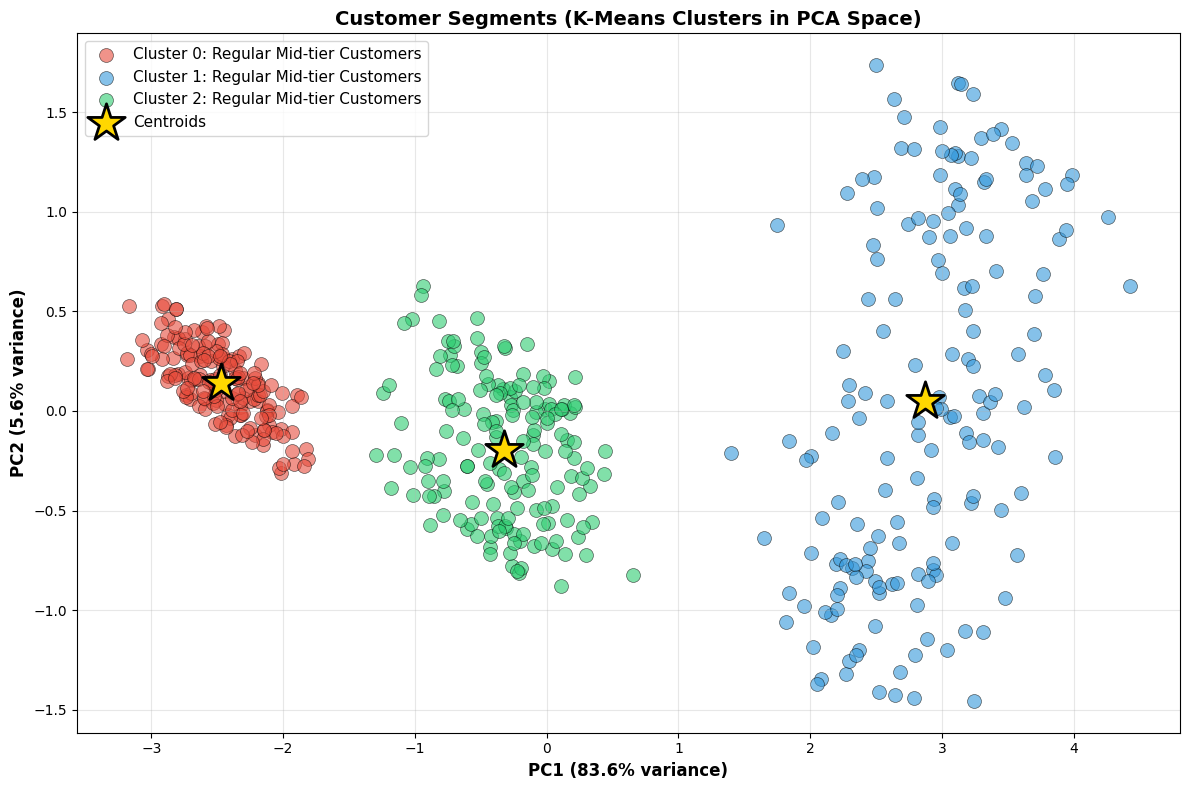


Visualization complete! The plot shows clear separation between customer segments.


In [15]:
# Create scatter plot of PC1 vs PC2 colored by cluster
plt.figure(figsize=(12, 8))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
for cluster_id in range(optimal_k):
    mask = clusters == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=f'Cluster {cluster_id}: {cluster_names[cluster_id]}',
               c=colors[cluster_id], s=100, alpha=0.6, edgecolors='black', linewidth=0.5)

# Plot centroids in PCA space
centroids_pca = pca.transform(centroids_scaled)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           c='gold', marker='*', s=800, edgecolors='black', linewidth=2,
           label='Centroids', zorder=5)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12, fontweight='bold')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12, fontweight='bold')
plt.title('Customer Segments (K-Means Clusters in PCA Space)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nVisualization complete! The plot shows clear separation between customer segments.")